# Conceptual description

As people interact, they tend to become more alike in their beliefs, attitudes and behaviour. In ["The Dissemination of Culture: A Model with Local Convergence and Global Polarization" (1997)](https://www.jstor.org/stable/174371?seq=1#metadata_info_tab_contents), Robert Axelrod presents an agent-based model to explain cultural diffusion. Analogous to Schelling's segregation model, the key to this conceptualization is the emergence of polarization from the interaction of individual agents. The basic premise is that the more similar an agent is to a neighbor, the more likely that that actor will adopt one of the neighbor's traits.

In the model below, this is implemented by initializing the model by filling an excel-like grid with agents with random values [0,1] for each of four traits (music, sports, favorite color and drink). 

Each step, each agent (in random order) chooses a random neighbor from its neighbors proportionaly to how similar it is to each of its neighbors, and adopts one randomly selected differing trait from this neighbor. Similarity between any two agents is calculated by the sum of identical traits.

To visualize the model, the four traits are transformed into 'RGBA' (Red-Green-Blue-Alpha) values; i.e. a color and an opacity. The visualizations below show the clusters of homogeneity being formed.

## implement the step method of the agent
The first assignment is to implement the step method for the agent. 

1. Make a conceptual description or diagram of the step method for the agent in light of the description given above.
2. implement the step method.
    * you need to use self.cell.get_neighborhood in order to make it work with varying neighborhood sizes
    * self.random.choices takes an optional weights keyword argument allowing you to randomly yet proportionaly to similiary select a neighbor

Compare your results with those shown below
<div>
<img src="dynamics.png" width="600"/>
</div>

In [1]:
import collections
import random

import numpy as np

from mesa import Model
from mesa.datacollection import DataCollector

from mesa.experimental.cell_space import CellAgent, OrthogonalMooreGrid


class CulturalDiff(Model):
    """
    Model class for the Schelling segregation model.
    
    Parameters
    ----------
    height : int
             height of grid
    width : int
            height of grid
    seed : int
            random seed
    neighborhoood_size : int, optional
    torus : bool, optional
    
    Attributes
    ----------
    height : int
    width : int
    density : float
    schedule : RandomActivation instance
    grid : SingleGrid instance
    
    """


    def __init__(self, height=20, width=20, seed=None,
                neighborhood_size=1, torus=True):
        super().__init__(seed=seed)

        self.grid = OrthogonalMooreGrid((width, height), torus=torus, capacity=1, random=self.random)
        self.datacollector = DataCollector(model_reporters={'diversity':calculate_nr_of_cultures})

        # Fill grid with agents with random traits
        
        # Note that this implementation does not guarantee some set distribution of traits. 
        # Therefore, examining the effect of minorities etc is not facilitated.

        for cell in self.grid.all_cells:
            profile = np.asarray([self.random.choice([0,1]) for _ in range(4)])
            
            agent = CulturalDiffAgent(self, profile, neighborhood_size)
            agent.cell = cell

        self.datacollector.collect(self)

    def step(self):
        """
        Run one step of the model.
        """
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)


class CulturalDiffAgent(CellAgent):
    """
    Schelling segregation agent
    
    Parameters
    ----------
    model : Model instance
    profile : ndarray
    
    """

    def __init__(self, model, profile, neighborhood_size):
        super().__init__(model)
        self.profile = profile
        self.neighborhood_size = neighborhood_size
        
    def step(self):
        neighbor_similarity_dict = {}
        for neighbor in self.cell.get_neighborhood(radius=self.neighborhood_size).agents:
            neighbor_similarity = np.sum(self.profile==neighbor.profile)
            neighbor_similarity_dict[neighbor] = neighbor_similarity
        
        # Proportional to this similarity, pick a 'random' neighbor to interact with
        #weights become the chances of being selected
        #zero added to the selecion of the neighbour because the random.choices function returns a lsit from which we only need the first element (the selected neighbor)
        neighbor_to_interact = self.random.choices(list(neighbor_similarity_dict.keys()),weights=neighbor_similarity_dict.values())[0]
        
        # Select a trait that differs between the selected neighbor and self and change that trait in self
        # we are using some numpy boolean indexing to make this short and easy
        not_same_features = self.profile != neighbor_to_interact.profile
        
        if np.any(not_same_features):
            index_for_trait = self.random.choice(np.nonzero(not_same_features)[0].tolist())
            self.profile[index_for_trait] = neighbor_to_interact.profile[index_for_trait]


def traits_to_color(profile):  
    """ Converts the traits of an agent to a list of RGBA values"""
    color = profile.copy().astype(float)
    if color[-1]==0:
        color[-1] = 0.2
    return color


def calculate_nr_of_cultures(model):
    #Creates a dictionary that auto-initializes any new key to 0. It will be used to group agents by their profile.
    diversity = collections.defaultdict(int)
    for agent in model.agents:
         # agent.profile is a NumPy array (e.g. [0, 1, 1, 0]), which cannot be used as a dictionary key because arrays are mutable and not hashable.
        # Converting to tuple (e.g. (0, 1, 1, 0)) makes it hashable, so it can serve as a unique key representing one distinct culture.
        diversity[tuple(agent.profile)] += 1
        # Each unique profile gets its own key; the counter tracks how many agents share that culture (the value of the key) (e.g. {(0,1,1,0): 14, (1,0,0,1): 8, ...})


    return len(diversity.keys())

/var/folders/hr/5k7_qdqs61lfllhj97j5fy8w0000gn/T/ipykernel_26415/633919858.py:9: DeprecationWarning: you are importing from mesa.experimental.cell_space, all cell spaces have been moved to mesa.discrete_space
  from mesa.experimental.cell_space import CellAgent, OrthogonalMooreGrid


In [2]:
# Create initial model instance
#this syantx overrides the first two parameters of the model, so hgiht and width of the grid are set to 50 instead of the default 20. This is just to make the dynamics more visible, but you can experiment with different sizes.
model = CulturalDiff(50, 50)

for _ in range(10):
    model.step()

# Visualization

In [3]:
from mesa.visualization import (
    SolaraViz,
    make_plot_component,
    make_space_component,
)
from mesa.visualization.components import AgentPortrayalStyle

<IPython.core.display.Javascript object>

/Users/precupada/Documents/Academics/Masters/EPA/Year 2/Q3/EPA123 Intro to TPM/ABM/venv/lib/python3.13/site-packages/solara/validate_hooks.py:122: UserWarning: /Users/precupada/Documents/Academics/Masters/EPA/Year 2/Q3/EPA123 Intro to TPM/ABM/venv/lib/python3.13/site-packages/mesa/visualization/solara_viz.py:399: ComponentsView: `use_state` found despite early return on line 376
To suppress this check, replace the line with:
    current_tab_index, set_current_tab_index = solara.use_state(0)  # noqa: SH101

Make sure you understand the consequences of this, by reading about the rules of hooks at:
    https://solara.dev/documentation/advanced/understanding/rules-of-hooks

  warnings.warn(str(e))


In [4]:
def agent_portrayal(agent):
    return AgentPortrayalStyle(size=25, color=traits_to_color(agent.profile), marker='s')

model_params = {
    "neighborhood_size": {
        "type": "SliderInt",
        "value": 1,
        "label": "neighborhood size",
        "min": 1,
        "max": 4,
        "step": 1,
    },
    "width": 20,
    "height": 20,
}

# Create initial model instance
model = CulturalDiff(50, 50)

SpaceGraph = make_space_component(agent_portrayal)
DiversityPlot = make_plot_component("diversity")

page = SolaraViz(
    model,
    components=[SpaceGraph, DiversityPlot],
    model_params=model_params,
    name="Cultural diffusion",
)
# This is required to render the visualization in the Jupyter notebook
page


Cannot show ipywidgets in text

# Immediate impression of the model

The initial exploration of the model shows that there is a cyclical pattern to the diversity a population of agents observes. The diversity starts off in equilibrium, but it seems around every 100 steps there is a big loss of diversity, after which another period of stability settles in before dropping again after 100 steps. It seems there is a certain constant speed at which cultural diffusion occurs and at which, ultimately, certain agent profiles die down. 

## Comparison to given results from profesor

The cyclical behaviour is also noticeable in the given visualization of the lecturing team. Even though the drop in diversity is observed at different time steps and the level of diversity is much noisier in the given example, the differences can be accounted for by the stochasticity introduced in the choice of agent order, neighbour weights, random initialization, etc. 

In [10]:
# --- Radii comparison (1-3): run experiments ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def run_radius_experiments(
    radii=(1, 2, 3),
    n_runs=1,
    n_steps=300,
    width=50,
    height=50,
    torus=True,
    seed_base=1000,
):
    rows = []
    for run in range(n_runs):
        run_seed = seed_base + run  # reproducible + fair comparison across radii
        for radius in radii:
            model = CulturalDiff(
                height=height,
                width=width,
                seed=run_seed,
                neighborhood_size=radius,
                torus=torus,
            )
            for _ in range(n_steps):
                model.step()

            df = model.datacollector.get_model_vars_dataframe().reset_index()
            df = df.rename(columns={"index": "step"})
            df["run"] = run
            df["radius"] = radius
            rows.append(df[["run", "radius", "step", "diversity"]])

    return pd.concat(rows, ignore_index=True)

results = run_radius_experiments(radii=(1,2,3), n_runs=5, n_steps=300, width=50, height=50)
results.head()

,run,radius,step,diversity
0,0,1,0,16
1,0,1,1,16
2,0,1,2,16
3,0,1,3,16
4,0,1,4,16


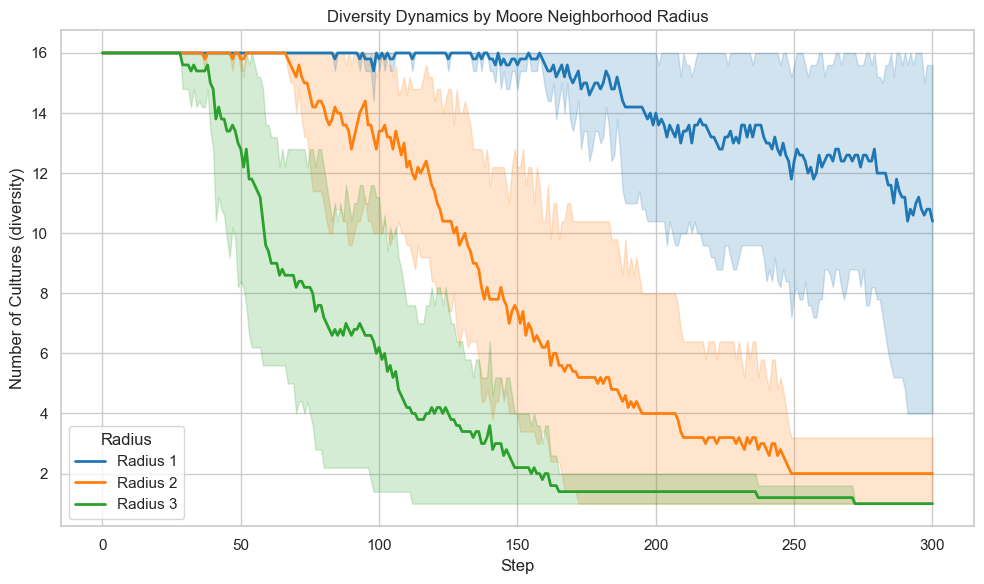

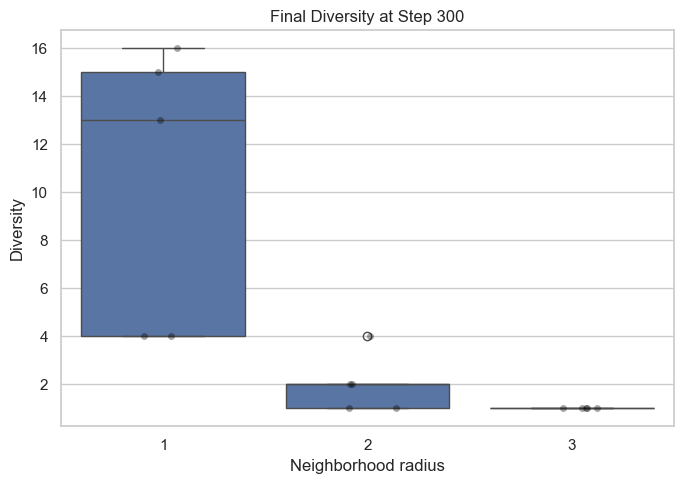

,mean,std,median,min,max
radius,,,,,
1,10.4,5.941380,13.0,4,16
2,2.0,1.224745,2.0,1,4
3,1.0,0.000000,1.0,1,1


In [11]:
# --- Plot dynamics over time + final comparison ---
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

palette = sns.color_palette("tab10", n_colors=results["radius"].nunique())

for color, radius in zip(palette, sorted(results["radius"].unique())):
    sub = results[results["radius"] == radius]
    g = sub.groupby("step")["diversity"]

    mean = g.mean()
    q10 = g.quantile(0.10)
    q90 = g.quantile(0.90)

    ax.plot(mean.index, mean.values, lw=2, color=color, label=f"Radius {radius}")
    ax.fill_between(mean.index, q10.values, q90.values, color=color, alpha=0.2)

ax.set_title("Diversity Dynamics by Moore Neighborhood Radius")
ax.set_xlabel("Step")
ax.set_ylabel("Number of Cultures (diversity)")
ax.legend(title="Radius")
plt.tight_layout()
plt.show()

# Final-step comparison (boxplot)
final_step = results["step"].max()
final_df = results[results["step"] == final_step]

plt.figure(figsize=(7, 5))
sns.boxplot(data=final_df, x="radius", y="diversity")
sns.stripplot(data=final_df, x="radius", y="diversity", color="black", alpha=0.35, jitter=0.15)
plt.title(f"Final Diversity at Step {final_step}")
plt.xlabel("Neighborhood radius")
plt.ylabel("Diversity")
plt.tight_layout()
plt.show()

# Numeric summary for reporting
summary = final_df.groupby("radius")["diversity"].agg(["mean", "std", "median", "min", "max"])
display(summary)

# Neighborhood size

The original version of the model uses a Moore neighborhood with a radius of 1. Explore the dynamics of the model with radius ranging from 1-3. How do the dynamics of the model change, and why?

1. Perform experiments for neighborhoods with radiuses ranging from 1-3. Don't forget to account for the stochastic uncertainty
2. Make an appropriate visualization showing the difference in dynamics over time for both versions of the model
3. Describe in words how the behavior is different and explain this change in behavior.

All three runs have a decalining trend in common, showing that cultural diffusion and profile dominance is occurring in all three versions of the model. However, the speed at which this occurs seems to be different across the three versions. The larger the neighborhood size, the faster the decline in diversity. This can be explained by the fact that with a larger neighborhood size, agents have more neighbors to interact with and thus more opportunities to become similar to others, which accelerates the process of cultural diffusion and leads to a faster decline in diversity. Additionally, the larger neighborhood size may also lead to more rapid convergence towards dominant profiles, as agents are more likely to interact with and adopt traits from a wider range of neighbors, which can further accelerate the decline in diversity. The final-step comparison also shows that the median diversity is lowest for radius 3, followed by radius 2 and then radius 1, which supports the observation that larger neighborhood sizes lead to faster declines in diversity. 

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def run_torus_experiments(
    torus_options=(True, False),
    n_runs=5,
    n_steps=300,
    width=40,
    height=40,
    neighborhood_size=1,
    seed_base=2000,
):
    rows = []

    for run in range(n_runs):
        run_seed = seed_base + run  # same seed for both torus settings in each run
        for torus in torus_options:
            model = CulturalDiff(
                height=height,
                width=width,
                seed=run_seed,
                neighborhood_size=neighborhood_size,
                torus=torus,
            )

            for _ in range(n_steps):
                model.step()

            df = model.datacollector.get_model_vars_dataframe().reset_index()
            df = df.rename(columns={"index": "step"})
            df["run"] = run
            df["torus"] = torus
            rows.append(df[["run", "torus", "step", "diversity"]])

    return pd.concat(rows, ignore_index=True)

# Run experiments
torus_results = run_torus_experiments(
    torus_options=(True, False),
    n_runs=5,
    n_steps=300,
    width=40,
    height=40,
    neighborhood_size=1,
)

torus_results.head()

,run,torus,step,diversity
0,0,True,0,16
1,0,True,1,16
2,0,True,2,16
3,0,True,3,16
4,0,True,4,16


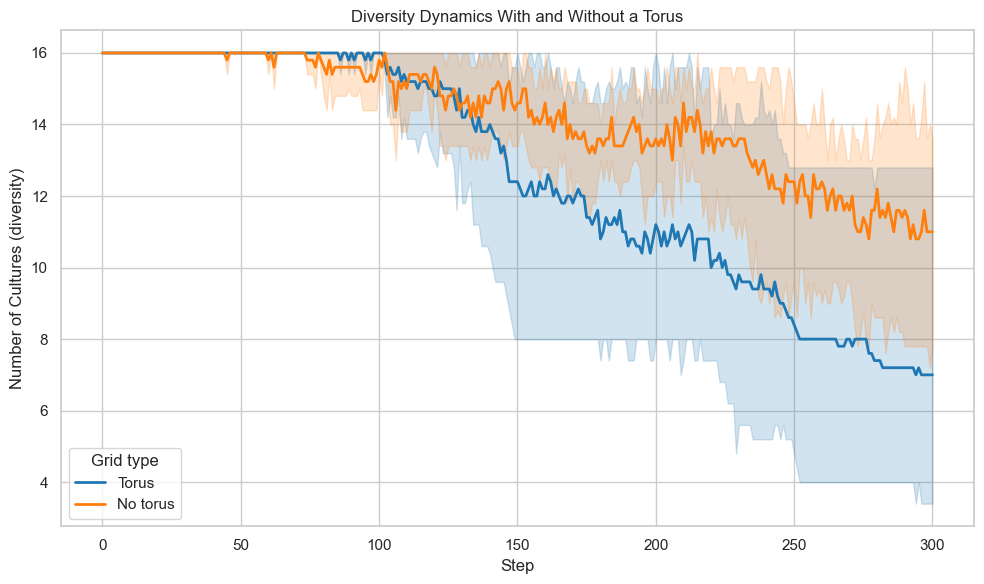

In [15]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

labels = {True: "Torus", False: "No torus"}
colors = {True: "tab:blue", False: "tab:orange"}

for torus in [True, False]:
    sub = torus_results[torus_results["torus"] == torus]
    g = sub.groupby("step")["diversity"]

    mean = g.mean()
    q10 = g.quantile(0.10)
    q90 = g.quantile(0.90)

    ax.plot(mean.index, mean.values, lw=2, color=colors[torus], label=labels[torus])
    ax.fill_between(mean.index, q10.values, q90.values, color=colors[torus], alpha=0.2)

ax.set_title("Diversity Dynamics With and Without a Torus")
ax.set_xlabel("Step")
ax.set_ylabel("Number of Cultures (diversity)")
ax.legend(title="Grid type")
plt.tight_layout()
plt.show()

# Torus
To deal with edge effects, the model assumes the use of a Torus (i.e., donut). In reality, geography matters a lot and thus edge effects can occur. Explore the dynamics of the model with and without assuming a torus. How does the behaviour of the model change, and why?

1. Perform experiments to test the behavior of the model with and without assuming a torus. Don't forget to account for the stochastic uncertainty
2. Make an appropriate visualization showing the difference in dynamics over time for both versions of the model
Describe in words how the behavior is different and explain this change in behavior.

Again, we observe the same declining trend in diversity for both versions of the model, which shows that cultural diffusion is occurring in both cases. However, the speed at which this occurs seems to be different across the two versions. The version with a torus shows a faster decline in diversity compared to the version without a torus. This can be explained by the fact that in a torus, agents at the edges of the grid can interact with agents on the opposite edge, which increases the number of potential interactions and accelerates the process of cultural diffusion. In contrast, in a non-torus grid, agents at the edges have fewer neighbors to interact with, which can slow down the diffusion process and lead to a slower decline in diversity. The final-step comparison also shows that the median diversity is lower for the torus version compared to the non-torus version, which supports the observation that assuming a torus leads to faster declines in diversity.

# Neighbor interaction
The provided implementation assumes that interaction is random yet proportional to how similar the neighbors are. What if instead, we assume completely random interaction? How does the behavior of the model change, and why?

Note that in order to do this, you will have to change the existing implementation:

* add a select_random keyword argument to the mode
* set select_random as a class attribute on the Agent class
* add a select_random_neigbor and select_weighted_random_neigbor method to the Agent class
* pick which select_* method to use based on the value of the select_random class attribute

1. Implement the modified model and agent
2. Perform experiments for both random and weighted random selection of neighbors. Don't forget to account for the stochastic uncertainty
3. Make an appropriate visualization showing the difference in dynamics over time for both versions of the model
4. Describe in words how the behavior is different and explain this change in behavior.
5. Conceptually, how would you change the original implementation of the model as used for the first assignment such that the extensions needed for this assignment could have been implemented by merely extending the model and agent class.


5. to avoid having to change the original implementation, we could have created a new subclass of the original model and agent class. In the new agent subclass, we could have added the select_random class attribute and the two methods for selecting neighbors. In the new model subclass, we could have added the select_random keyword argument and set it as a class attribute on the new agent subclass. This way, we could have implemented the modified behavior without changing the original implementation, allowing us to easily switch between the two versions of the model by simply using different subclasses.

In [16]:
class CulturalDiffInteraction(Model):
    """
    Cultural diffusion model with two neighbor-selection modes:

    - select_random = False:
        weighted random interaction, proportional to similarity
    - select_random = True:
        completely random neighbor interaction
    """

    def __init__(
        self,
        height=20,
        width=20,
        seed=None,
        neighborhood_size=1,
        torus=True,
        select_random=False,
    ):
        super().__init__(seed=seed)

        self.select_random = select_random
        self.grid = OrthogonalMooreGrid(
            (width, height),
            torus=torus,
            capacity=1,
            random=self.random,
        )
        self.datacollector = DataCollector(
            model_reporters={"diversity": calculate_nr_of_cultures}
        )

        # Assignment asks for select_random to be set as a class attribute
        # on the Agent class. We do that here before creating agents.
        # To avoid problems when comparing multiple models in one notebook,
        # each agent will copy this value to an instance attribute in __init__.
        CulturalDiffInteractionAgent.select_random = select_random

        for cell in self.grid.all_cells:
            profile = np.asarray([self.random.choice([0, 1]) for _ in range(4)])
            agent = CulturalDiffInteractionAgent(self, profile, neighborhood_size)
            agent.cell = cell

        self.datacollector.collect(self)

    def step(self):
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)


class CulturalDiffInteractionAgent(CellAgent):
    """
    Agent for the modified neighbor-interaction assignment.
    """

    # default class attribute; overwritten by the model before agent creation
    select_random = False

    def __init__(self, model, profile, neighborhood_size):
        super().__init__(model)
        self.profile = profile
        self.neighborhood_size = neighborhood_size

        # Copy class attribute to instance attribute so that if you later create
        # another model with a different setting, already-existing agents keep
        # their own selection rule.
        self.select_random = self.__class__.select_random

    def get_neighbor_similarity_dict(self):
        """
        Build a dictionary:
            key   -> neighbor agent
            value -> number of matching traits with self
        """
        neighbor_similarity_dict = {}

        neighbors = list(
            self.cell.get_neighborhood(radius=self.neighborhood_size).agents
        )

        for neighbor in neighbors:
            similarity = np.sum(self.profile == neighbor.profile)
            neighbor_similarity_dict[neighbor] = similarity

        return neighbor_similarity_dict

    def select_random_neighbor(self, neighbors):
        """
        Choose one neighbor uniformly at random.
        """
        if not neighbors:
            return None
        return self.random.choice(neighbors)

    def select_weighted_random_neighbor(self, neighbor_similarity_dict):
        """
        Choose one neighbor randomly, but with probability proportional
        to similarity.

        If all similarities are 0, no interaction takes place.
        """
        if not neighbor_similarity_dict:
            return None

        neighbors = list(neighbor_similarity_dict.keys())
        weights = list(neighbor_similarity_dict.values())

        # If total similarity is zero, random.choices would fail and,
        # conceptually, no interaction should happen anyway.
        if sum(weights) == 0:
            return None

        return self.random.choices(neighbors, weights=weights, k=1)[0]

    def step(self):
        neighbor_similarity_dict = self.get_neighbor_similarity_dict()

        if self.select_random:
            neighbor_to_interact = self.select_random_neighbor(
                list(neighbor_similarity_dict.keys())
            )
        else:
            neighbor_to_interact = self.select_weighted_random_neighbor(
                neighbor_similarity_dict
            )

        if neighbor_to_interact is None:
            return

        # Find which traits differ between self and the selected neighbor
        not_same_features = self.profile != neighbor_to_interact.profile

        # If there is at least one differing trait, copy one of those traits
        # from the selected neighbor
        if np.any(not_same_features):
            differing_trait_indices = np.nonzero(not_same_features)[0].tolist()
            index_for_trait = self.random.choice(differing_trait_indices)
            self.profile[index_for_trait] = neighbor_to_interact.profile[index_for_trait]

In [17]:
""" 
Quick check that both models work
"""

weighted_model = CulturalDiffInteraction(
    width=20, height=20, neighborhood_size=1, torus=True, seed=1, select_random=False
)

random_model = CulturalDiffInteraction(
    width=20, height=20, neighborhood_size=1, torus=True, seed=1, select_random=True
)

for _ in range(5):
    weighted_model.step()
    random_model.step()

weighted_model.datacollector.get_model_vars_dataframe().head(), random_model.datacollector.get_model_vars_dataframe().head()

(   diversity
 0         16
 1         16
 2         16
 3         16
 4         16,
    diversity
 0         16
 1         16
 2         16
 3         16
 4         16)

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def run_neighbor_selection_experiments(
    select_random_options=(False, True),
    n_runs=5,
    n_steps=200,
    width=35,
    height=35,
    neighborhood_size=1,
    torus=True,
    seed_base=3000,
):
    rows = []

    for run in range(n_runs):
        run_seed = seed_base + run  # same initialization for both versions

        for select_random in select_random_options:
            model = CulturalDiffInteraction(
                height=height,
                width=width,
                seed=run_seed,
                neighborhood_size=neighborhood_size,
                torus=torus,
                select_random=select_random,
            )

            for _ in range(n_steps):
                model.step()

            df = model.datacollector.get_model_vars_dataframe().reset_index()
            df = df.rename(columns={"index": "step"})
            df["run"] = run
            df["select_random"] = select_random
            rows.append(df[["run", "select_random", "step", "diversity"]])

    return pd.concat(rows, ignore_index=True)


interaction_results = run_neighbor_selection_experiments(
    select_random_options=(False, True),
    n_runs=15,
    n_steps=200,
    width=35,
    height=35,
    neighborhood_size=1,
    torus=True,
)

interaction_results.head()

,run,select_random,step,diversity
0,0,False,0,16
1,0,False,1,16
2,0,False,2,16
3,0,False,3,16
4,0,False,4,16


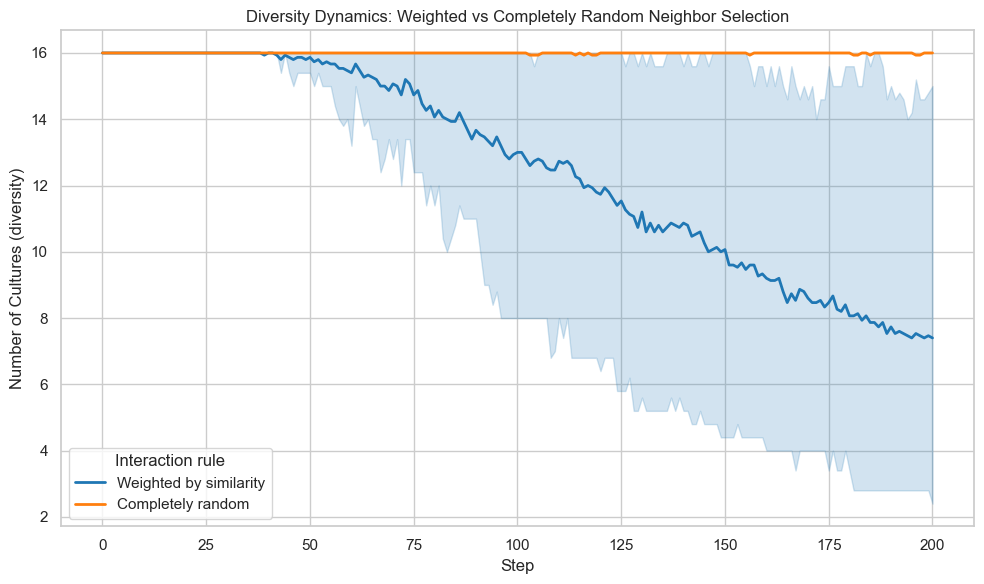

In [22]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

labels = {
    False: "Weighted by similarity",
    True: "Completely random",
}
colors = {
    False: "tab:blue",
    True: "tab:orange",
}

for select_random in [False, True]:
    sub = interaction_results[interaction_results["select_random"] == select_random]
    g = sub.groupby("step")["diversity"]

    mean = g.mean()
    q10 = g.quantile(0.10)
    q90 = g.quantile(0.90)

    ax.plot(mean.index, mean.values, lw=2, color=colors[select_random], label=labels[select_random])
    ax.fill_between(mean.index, q10.values, q90.values, color=colors[select_random], alpha=0.2)

ax.set_title("Diversity Dynamics: Weighted vs Completely Random Neighbor Selection")
ax.set_xlabel("Step")
ax.set_ylabel("Number of Cultures (diversity)")
ax.legend(title="Interaction rule")
plt.tight_layout()
plt.show()

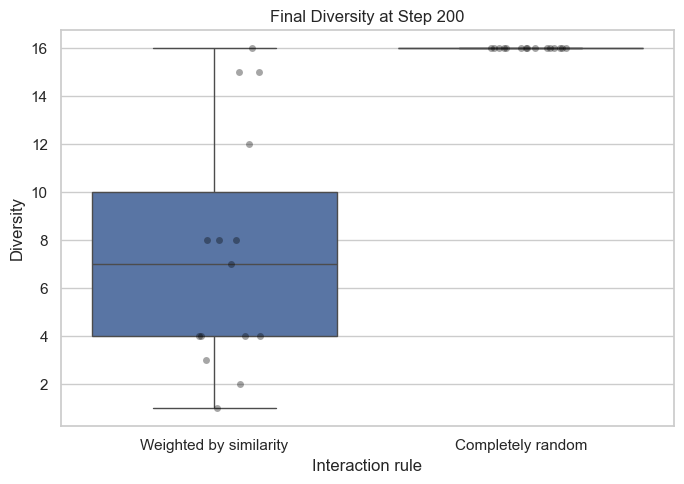

,mean,std,median,min,max
interaction_rule,,,,,
Completely random,16.0,0.000000,16.0,16,16
Weighted by similarity,7.4,4.982828,7.0,1,16


In [23]:
final_step = interaction_results["step"].max()
final_df = interaction_results[interaction_results["step"] == final_step].copy()
final_df["interaction_rule"] = final_df["select_random"].map(labels)

plt.figure(figsize=(7, 5))
sns.boxplot(data=final_df, x="interaction_rule", y="diversity")
sns.stripplot(
    data=final_df,
    x="interaction_rule",
    y="diversity",
    color="black",
    alpha=0.35,
    jitter=0.15,
)
plt.title(f"Final Diversity at Step {final_step}")
plt.xlabel("Interaction rule")
plt.ylabel("Diversity")
plt.tight_layout()
plt.show()

summary = final_df.groupby("interaction_rule")["diversity"].agg(
    ["mean", "std", "median", "min", "max"]
)
display(summary)

There is no variation or recognizible trend when the selction criteria is completely random. This can be explained by the fact that with completely random interaction, agents are just as likely to interact with very different neighbors as they are to interact with similar neighbors. This means that there is no systematic pressure for agents to become more similar to their neighbors, which can lead to a more stable level of diversity over time. In contrast, when interaction is weighted by similarity, agents are more likely to interact with and adopt traits from similar neighbors, which can create a positive feedback loop that accelerates the process of cultural diffusion and leads to a decline in diversity. The final-step comparison also shows that the median diversity is higher for the completely random interaction compared to the weighted interaction, which supports the observation that completely random neighbor selection leads to more stable diversity levels.